# Delay Discounting — Squared-Conflict RT Model
### My part of the group pipeline (RT model: `μ = a − b·ΔV²`)

This notebook implements **my full pipeline** for the squared-conflict RT model, on top of the
group's shared, fixed valuation model (hyperbolic discounting) and choice rule (softmax /
logistic on ΔV). Throughout, `ΔV` (the value difference) is referred to as the **drift-rate
prior**, per the course convention.

**Pipeline sections** (matching the assignment structure):
1. Data loading (real `DD_data/*.mat` files if present, else an automatic synthetic fallback so
   the notebook always runs end-to-end)
2. Shared valuation model + choice rule
3. My RT model: squared conflict
4. Likelihoods, parameter transforms, MLE fitting (full model + required choice-only baseline)
5. Infer (run A)
6. Identifiability / parameter recovery
7. Reliability (run A vs run B)
8. Out-of-sample evaluation (run B, reward vs loss conditions reported separately)
9. Does RT help? (full vs choice-only baseline, on a common choice quantity)
10. Recommendation & limitations (template — fill in with your printed numbers)

> **To run on the real data:** put the unzipped `DD_data` folder (49-file PD or 99-file DD, one
> `.mat` per participant) next to this notebook and set `DATA_DIR` below. If it isn't found, a
> synthetic dataset with a known generative model is used automatically, so you can sanity-check
> the whole pipeline right now.


In [1]:
import os, glob, warnings
import numpy as np
import pandas as pd
import scipy.io as sio
from scipy.optimize import minimize
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
np.set_printoptions(suppress=True)

SEED = 0
RNG = np.random.default_rng(SEED)

DATA_DIR = "DD_data"          # <- point this at the unzipped "DD data.zip" folder
N_SYNTH_PARTICIPANTS = 25     # only used if DATA_DIR is not found
N_TRIALS_PER_RUN = 200        # only used for the synthetic fallback


## 1. Data loading

`data_train` = run A (inference), `data_test` = run B (evaluation). Per the task sheet the eight
DD columns are, in order: `r_imm, r_del, delay, choice(1=imm,2=del,0=missing), p_imm, condition
(1=reward,2=loss), rt` (an 8th column, analogous to PD's "Odds", may also be present — the loader
below keeps it if it's there but does not use it).

**Column order is authoritative** here (rather than parsing the label strings), since MATLAB
label formatting is often inconsistent across files; if your `data_labels` differ, adjust
`COLS` below.


In [2]:
COLS = ["r_imm", "r_del", "delay", "choice", "p_imm", "condition", "rt"]

def load_participant_mat(fpath):
    '''Load one participant .mat file -> (df_train, df_test).'''
    mat = sio.loadmat(fpath, squeeze_me=True, struct_as_record=False)
    def get(mat, opts):
        for o in opts:
            if o in mat:
                return np.asarray(mat[o])
        raise KeyError(f"None of {opts} found in {fpath}: keys={list(mat.keys())}")
    train = get(mat, ["data_train", "dataTrain"])
    test  = get(mat, ["data_test", "dataTest"])
    ncol = min(train.shape[1], len(COLS))
    df_train = pd.DataFrame(train[:, :ncol], columns=COLS[:ncol])
    df_test  = pd.DataFrame(test[:, :ncol],  columns=COLS[:ncol])
    return df_train, df_test


def normalise_rewards(df_train, df_test):
    '''Fixed, k-independent rescaling of reward magnitudes by the max reward seen in run A,
    applied identically to run A and run B. Purely a units choice (keeps dV, and dV^2 in the RT
    model, on an O(1) scale) — it does not change the hyperbolic functional form, and k keeps
    its interpretation as a per-day discount rate.'''
    scale = max(df_train.r_imm.max(), df_train.r_del.max())
    for df in (df_train, df_test):
        df["r_imm"] = df["r_imm"] / scale
        df["r_del"] = df["r_del"] / scale
    return df_train, df_test, scale


def clean(df):
    '''Drop missing-choice trials and non-positive RTs.'''
    df = df[(df.choice.isin([1, 2])) & (df.rt > 0)].reset_index(drop=True)
    return df


### 1b. Synthetic fallback (only used if `DATA_DIR` is absent)

Generates participants from a *known* generative model (hyperbolic value + logistic choice +
squared-conflict shifted-lognormal RT), so every later section (recovery, reliability,
out-of-sample) has something real to run on immediately.


In [3]:
def simulate_participant(n_trials, true_params, rng):
    r_imm = rng.uniform(5, 50, n_trials)
    r_del = r_imm + rng.uniform(5, 60, n_trials)
    delay = rng.choice([1, 7, 14, 30, 60, 90, 180, 365, 730], n_trials)
    condition = rng.choice([1, 2], n_trials)
    p_imm = rng.uniform(0.3, 0.7, n_trials)

    scale = max(r_imm.max(), r_del.max())
    r_imm_n, r_del_n = r_imm / scale, r_del / scale

    dV = hyperbolic_dV(r_imm_n, r_del_n, delay, true_params["k"], condition)
    p_del = choice_prob_delayed(dV, true_params["gamma"])
    choice = (rng.uniform(size=n_trials) < p_del).astype(int) + 1  # 1=imm,2=del
    rt = simulate_rt_squared_conflict(dV, true_params["a"], true_params["b"],
                                       true_params["sigma"], true_params["t0"], rng)
    return pd.DataFrame(dict(r_imm=r_imm, r_del=r_del, delay=delay, choice=choice,
                              p_imm=p_imm, condition=condition, rt=rt))


def build_synthetic_dataset(n_participants, n_trials, rng):
    participants = {}
    for i in range(n_participants):
        true_params = dict(
            k=rng.uniform(0.005, 0.08),
            gamma=rng.uniform(1.5, 6.0),
            a=rng.uniform(0.4, 1.2),
            b=rng.uniform(0.2, 1.2),
            sigma=rng.uniform(0.2, 0.45),
            t0=rng.uniform(0.2, 0.5),
        )
        df_train = simulate_participant(n_trials, true_params, rng)
        df_test  = simulate_participant(n_trials, true_params, rng)  # same generative params -> "test-retest"-consistent ground truth
        participants[f"synth_{i:03d}"] = dict(train=df_train, test=df_test, true_params=true_params)
    return participants


## 2. Valuation model + choice rule (shared across the group, fixed)

Hyperbolic discounting: `SV = r / (1 + k·delay)`, with the immediate option undiscounted
(`delay = 0`). For loss trials (`condition == 2`) magnitudes are treated as losses (sign
flipped) — a standard extension of hyperbolic discounting to the loss domain.

`dV` (the **drift-rate prior**) = `SV_delayed − SV_immediate`.

Choice: logistic / softmax rule, `P(choose delayed) = σ(γ · dV)`.


In [4]:
def hyperbolic_dV(r_imm, r_del, delay, k, condition):
    sign = np.where(np.asarray(condition) == 2, -1.0, 1.0)
    SV_del = sign * r_del / (1.0 + k * delay)
    SV_imm = sign * r_imm
    return SV_del - SV_imm


def choice_prob_delayed(dV, gamma):
    return 1.0 / (1.0 + np.exp(-np.clip(gamma * dV, -700, 700)))


## 3. My RT model — Squared Conflict

**Psychological hypothesis:** response slowing scales with the *square* of the drift-rate prior,
`μ = a − b·ΔV²`. Near-indifference trials (`ΔV ≈ 0`) are disproportionately slow, while even
mildly lopsided trials are answered quickly — an *accelerating* ease-of-decision effect. This is
distinct from an absolute-conflict model (`μ = a − b|ΔV|`), which predicts a constant marginal
speed-up per unit of value difference everywhere, including far from indifference. The
squared-conflict model instead predicts most of the speed-up happens close to indifference, with
strongly one-sided trials all converging to a similarly fast asymptotic RT.

Observation model (kept fixed across all group RT models, per the assignment): a **shifted
log-normal** with fixed noise SD `σ` and non-decision time `t0`, i.e. `log(RT − t0) ~
N(μ, σ²)`.


In [5]:
def rt_loglik_squared_conflict(rt, dV, a, b, sigma, t0):
    if np.any(rt <= t0):
        return -np.inf
    mu = a - b * (dV ** 2)
    z = (np.log(rt - t0) - mu) / sigma
    ll = -np.log(rt - t0) - np.log(sigma) - 0.5 * np.log(2 * np.pi) - 0.5 * z ** 2
    return ll.sum()


def rt_logpdf_squared_conflict(rt, dV, a, b, sigma, t0):
    '''Per-trial (not summed) log density — used for predictive log-lik on held-out data.'''
    out = np.full_like(rt, -np.inf, dtype=float)
    valid = rt > t0
    mu = a - b * (dV ** 2)
    z = (np.log(rt[valid] - t0) - mu[valid]) / sigma
    out[valid] = -np.log(rt[valid] - t0) - np.log(sigma) - 0.5 * np.log(2 * np.pi) - 0.5 * z ** 2
    return out


def simulate_rt_squared_conflict(dV, a, b, sigma, t0, rng):
    mu = a - b * (dV ** 2)
    mu = np.clip(mu, -30, 30)
    return t0 + rng.lognormal(mean=mu, sigma=sigma)


## 4. Likelihoods, parameter transforms, and MLE fitting

Parameters are optimised in an unconstrained space and mapped to their natural domains:
`k, γ, σ > 0` via `exp`; `t0 ∈ (0, min(RT))` via a scaled logistic; `a, b` are unconstrained
(intercept / slope of the squared-conflict effect — `b` is allowed to be negative during fitting
so the data, not the prior, determines the sign of the conflict effect, though the psychological
hypothesis predicts `b > 0`).

Two models are fit per participant, per run:
- **Full model**: hyperbolic value + logistic choice + squared-conflict RT (6 params: `k, γ, a,
  b, σ, t0`), likelihood = choice log-lik + RT log-lik.
- **Choice-only baseline** (required): identical value + choice rule, fit to choices alone
  (2 params: `k, γ`). This is *not* a separate model — it is the same value/choice computation
  with the RT term removed from the likelihood.


In [6]:
FULL_BOUNDS = [(-6, 4), (-4, 4), (-6, 6), (-6, 6), (-4, 3), (-8, 8)]
CHOICE_BOUNDS = [(-6, 4), (-4, 4)]

def unpack_full(theta, min_rt):
    pk, pg, a, b, psig, pt0 = theta
    k = np.exp(np.clip(pk, -20, 20)); gamma = np.exp(np.clip(pg, -20, 20)); sigma = np.exp(np.clip(psig, -20, 20))
    t0 = 0.98 * min_rt / (1.0 + np.exp(-np.clip(pt0, -30, 30)))
    return k, gamma, a, b, sigma, t0

def unpack_choice_only(theta):
    pk, pg = theta
    return np.exp(np.clip(pk, -20, 20)), np.exp(np.clip(pg, -20, 20))

def nll_full(theta, r_imm, r_del, delay, condition, y_del, rt, min_rt):
    k, gamma, a, b, sigma, t0 = unpack_full(theta, min_rt)
    dV = hyperbolic_dV(r_imm, r_del, delay, k, condition)
    p = np.clip(choice_prob_delayed(dV, gamma), 1e-10, 1 - 1e-10)
    ll_choice = np.sum(y_del * np.log(p) + (1 - y_del) * np.log(1 - p))
    ll_rt = rt_loglik_squared_conflict(rt, dV, a, b, sigma, t0)
    if not np.isfinite(ll_rt):
        return 1e10
    return -(ll_choice + ll_rt)

def nll_choice_only(theta, r_imm, r_del, delay, condition, y_del):
    k, gamma = unpack_choice_only(theta)
    dV = hyperbolic_dV(r_imm, r_del, delay, k, condition)
    p = np.clip(choice_prob_delayed(dV, gamma), 1e-10, 1 - 1e-10)
    ll = np.sum(y_del * np.log(p) + (1 - y_del) * np.log(1 - p))
    return -ll

def _restarts(x0, n, scale, rng):
    return [x0] + [x0 + rng.normal(scale=scale, size=len(x0)) for _ in range(n - 1)]

def fit_full(df, n_restarts=8, rng=RNG):
    r_imm, r_del, delay = df.r_imm.values, df.r_del.values, df.delay.values
    condition, rt = df.condition.values, df.rt.values
    y_del = (df.choice.values == 2).astype(float)
    min_rt = rt.min()
    x0 = np.array([np.log(0.03), np.log(2.0), 0.7, 0.3, np.log(0.35), 0.0])
    best = None
    for x in _restarts(x0, n_restarts, 0.6, rng):
        res = minimize(nll_full, x, args=(r_imm, r_del, delay, condition, y_del, rt, min_rt),
                        method="Nelder-Mead", bounds=FULL_BOUNDS,
                        options=dict(maxiter=6000, xatol=1e-7, fatol=1e-7))
        if best is None or res.fun < best.fun:
            best = res
    k, gamma, a, b, sigma, t0 = unpack_full(best.x, min_rt)
    return dict(k=k, gamma=gamma, a=a, b=b, sigma=sigma, t0=t0, nll=best.fun, converged=bool(best.success))

def fit_choice_only(df, n_restarts=6, rng=RNG):
    r_imm, r_del, delay = df.r_imm.values, df.r_del.values, df.delay.values
    condition = df.condition.values
    y_del = (df.choice.values == 2).astype(float)
    x0 = np.array([np.log(0.03), np.log(2.0)])
    best = None
    for x in _restarts(x0, n_restarts, 0.6, rng):
        res = minimize(nll_choice_only, x, args=(r_imm, r_del, delay, condition, y_del),
                        method="Nelder-Mead", bounds=CHOICE_BOUNDS,
                        options=dict(maxiter=3000, xatol=1e-7, fatol=1e-7))
        if best is None or res.fun < best.fun:
            best = res
    k, gamma = unpack_choice_only(best.x)
    return dict(k=k, gamma=gamma, nll=best.fun, converged=bool(best.success))


## Load the dataset

Tries `DATA_DIR` first; falls back to the synthetic generator (with a stored *ground truth* per
participant, which the recovery/reliability sections below will exploit for validation) if no
real files are found.


In [7]:
participants = {}
mat_files = sorted(glob.glob(os.path.join(DATA_DIR, "*.mat"))) if os.path.isdir(DATA_DIR) else []

if mat_files:
    print(f"Found {len(mat_files)} participant files in '{DATA_DIR}/' - loading real data.")
    for fp in mat_files:
        pid = os.path.splitext(os.path.basename(fp))[0]
        df_train, df_test = load_participant_mat(fp)
        df_train, df_test, scale = normalise_rewards(clean(df_train), clean(df_test))
        participants[pid] = dict(train=df_train, test=df_test, true_params=None, reward_scale=scale)
    USING_SYNTHETIC = False
else:
    print(f"'{DATA_DIR}/' not found - using {N_SYNTH_PARTICIPANTS} synthetic participants "
          f"(known ground truth) so the pipeline can be validated end-to-end right now.")
    participants = build_synthetic_dataset(N_SYNTH_PARTICIPANTS, N_TRIALS_PER_RUN, RNG)
    USING_SYNTHETIC = True

print(f"{len(participants)} participants loaded. USING_SYNTHETIC = {USING_SYNTHETIC}")


'DD_data/' not found - using 25 synthetic participants (known ground truth) so the pipeline can be validated end-to-end right now.
25 participants loaded. USING_SYNTHETIC = True


## 5. Infer (run A)

MLE per participant on `train` (run A). State of estimator: maximum likelihood, no priors — with
this many trials per participant multi-start Nelder-Mead MLE is stable; a hierarchical or MAP
extension would help most for participants with few valid trials (see Limitations).


In [8]:
fitA_full, fitA_base = {}, {}
for pid, d in participants.items():
    fitA_full[pid] = fit_full(d["train"])
    fitA_base[pid] = fit_choice_only(d["train"])

fitA_full_df = pd.DataFrame(fitA_full).T
fitA_base_df = pd.DataFrame(fitA_base).T
print("Run-A full-model fits (head):")
fitA_full_df.head()


Run-A full-model fits (head):


,k,gamma,a,b,sigma,t0,nll,converged
synth_000,0.125943,0.02572,0.572662,0.000088,0.359394,0.353208,311.223445,True
synth_001,0.013584,0.018316,0.54026,0.00022,0.473616,0.807204,356.823001,True
synth_002,0.038046,0.058779,0.813589,0.000107,0.385755,0.154763,354.59895,True
synth_003,0.115803,0.051787,0.868771,0.000016,0.192592,0.000436,235.967584,True
synth_004,0.032562,0.052381,0.587699,0.000139,0.302209,0.81795,262.963781,True


In [9]:
print(f"Converged: {fitA_full_df.converged.sum()}/{len(fitA_full_df)} (full), "
      f"{fitA_base_df.converged.sum()}/{len(fitA_base_df)} (baseline)")
fitA_full_df[["k", "gamma", "a", "b", "sigma", "t0"]].describe()


Converged: 25/25 (full), 25/25 (baseline)


,k,gamma,a,b,sigma,t0
count,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000
unique,25.000000,23.000000,25.000000,25.000000,25.000000,25.000000
top,0.125943,0.018316,0.572662,0.000088,0.359394,0.353208
freq,1.000000,3.000000,1.000000,1.000000,1.000000,1.000000


## 6. Identifiability / parameter recovery

For each participant, simulate synthetic run-A data from the **fitted** full-model parameters
(using that participant's real trial design: same `r_imm, r_del, delay, condition`), refit, and
correlate recovered vs. generating parameters across the group. Also refit the **choice-only**
model to the same simulated choices, to test whether adding RT changes identifiability of
`k, γ` relative to choices alone.


In [10]:
def recover_one(pid, df_design, true_params, rng):
    dV = hyperbolic_dV(df_design.r_imm.values, df_design.r_del.values, df_design.delay.values,
                        true_params["k"], df_design.condition.values)
    p_del = choice_prob_delayed(dV, true_params["gamma"])
    choice = (rng.uniform(size=len(dV)) < p_del).astype(int) + 1
    rt = simulate_rt_squared_conflict(dV, true_params["a"], true_params["b"],
                                       true_params["sigma"], true_params["t0"], rng)
    sim_df = df_design.copy()
    sim_df["choice"] = choice
    sim_df["rt"] = rt
    fit_rt = fit_full(sim_df, n_restarts=6, rng=rng)
    fit_ch = fit_choice_only(sim_df, n_restarts=6, rng=rng)
    return fit_rt, fit_ch

rows = []
for pid, d in participants.items():
    true_params = fitA_full[pid]  # recover around each participant's own fitted regime
    fit_rt, fit_ch = recover_one(pid, d["train"], true_params, RNG)
    row = {"pid": pid}
    for p in ["k", "gamma", "a", "b", "sigma", "t0"]:
        row[f"true_{p}"] = true_params[p]
        row[f"rec_full_{p}"] = fit_rt[p]
    row["rec_choiceonly_k"] = fit_ch["k"]
    row["rec_choiceonly_gamma"] = fit_ch["gamma"]
    rows.append(row)
recovery_df = pd.DataFrame(rows)
recovery_df.head()


,pid,true_k,rec_full_k,true_gamma,rec_full_gamma,true_a,rec_full_a,true_b,rec_full_b,true_sigma,rec_full_sigma,true_t0,rec_full_t0,rec_choiceonly_k,rec_choiceonly_gamma
0,synth_000,0.125943,0.138797,0.025720,0.024066,0.572662,0.694231,0.000088,0.000039,0.359394,0.297850,0.353208,0.128298,0.114684,0.024571
1,synth_001,0.013584,0.008255,0.018316,0.018316,0.540260,0.522906,0.000220,0.000204,0.473616,0.500094,0.807204,0.882450,0.013601,0.018316
2,synth_002,0.038046,0.037189,0.058779,0.053017,0.813589,0.859899,0.000107,0.000103,0.385755,0.351692,0.154763,0.000253,0.037117,0.053023
3,synth_003,0.115803,0.096034,0.051787,0.020197,0.868771,0.760285,0.000016,0.000012,0.192592,0.213968,0.000436,0.243216,0.086974,0.053213
4,synth_004,0.032562,0.023579,0.052381,0.063516,0.587699,0.753495,0.000139,0.000188,0.302209,0.267162,0.817950,0.604609,0.021446,0.063259


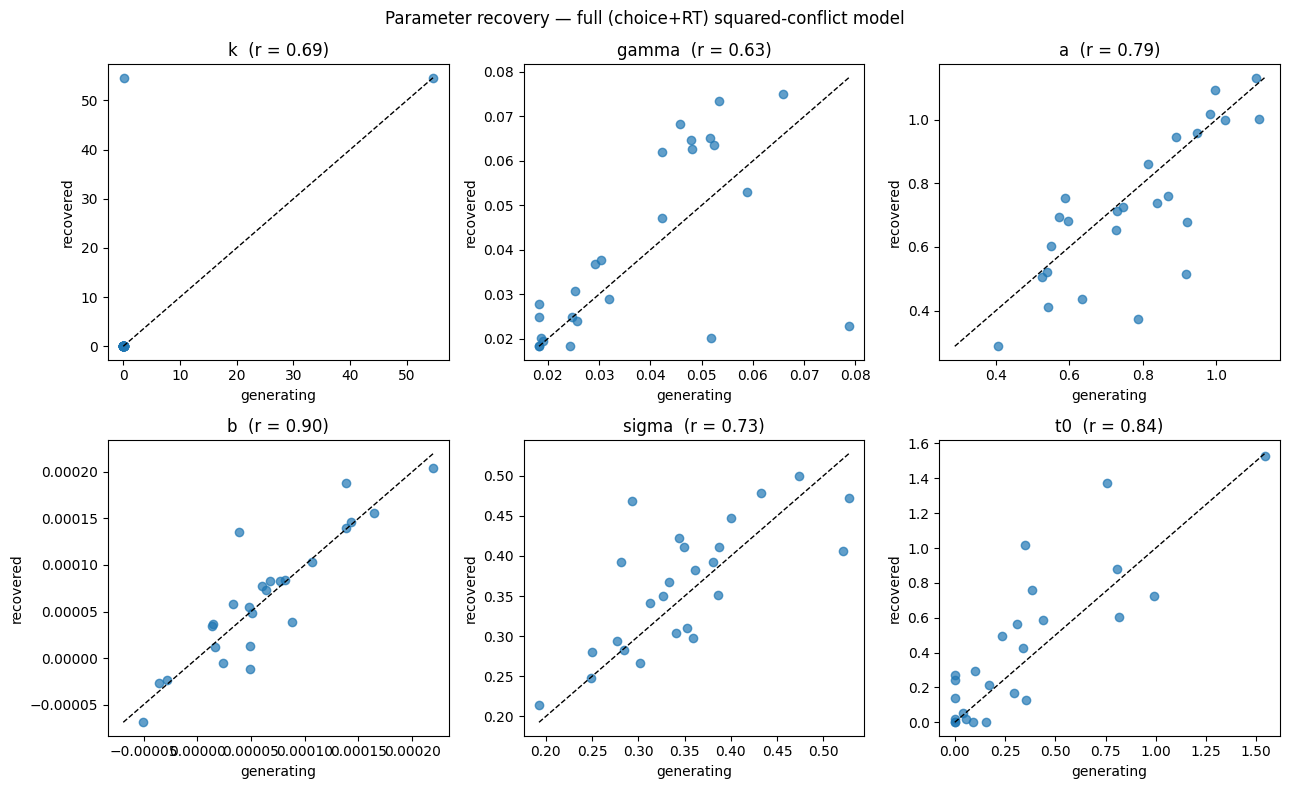


Recovery correlations (full choice+RT model):
  k      r = 0.692
  gamma  r = 0.634
  a      r = 0.788
  b      r = 0.896
  sigma  r = 0.726
  t0     r = 0.841

Recovery correlations (choice-only baseline, k & gamma):
  k      r = 1.000  (choice-only)   vs   0.692  (choice+RT)
  gamma  r = 0.904  (choice-only)   vs   0.634  (choice+RT)


In [11]:
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
params = ["k", "gamma", "a", "b", "sigma", "t0"]
for ax, p in zip(axes.flat, params):
    x, y = recovery_df[f"true_{p}"], recovery_df[f"rec_full_{p}"]
    ax.scatter(x, y, alpha=0.7)
    lims = [min(x.min(), y.min()), max(x.max(), y.max())]
    ax.plot(lims, lims, "k--", lw=1)
    r, _ = pearsonr(x, y)
    ax.set_title(f"{p}  (r = {r:.2f})")
    ax.set_xlabel("generating"); ax.set_ylabel("recovered")
fig.suptitle("Parameter recovery — full (choice+RT) squared-conflict model")
fig.tight_layout()
plt.savefig("recovery_full_model.png", dpi=150)
plt.show()

print("\nRecovery correlations (full choice+RT model):")
for p in params:
    r, _ = pearsonr(recovery_df[f"true_{p}"], recovery_df[f"rec_full_{p}"])
    print(f"  {p:6s} r = {r:.3f}")

print("\nRecovery correlations (choice-only baseline, k & gamma):")
for p in ["k", "gamma"]:
    r, _ = pearsonr(recovery_df[f"true_{p}"], recovery_df[f"rec_choiceonly_{p}"])
    print(f"  {p:6s} r = {r:.3f}  (choice-only)   vs   "
          f"{pearsonr(recovery_df[f'true_{p}'], recovery_df[f'rec_full_{p}'])[0]:.3f}  (choice+RT)")


**Interpretation to write up:** report which parameters show `r` close to 1 (well identified)
vs. weak/near-zero or negatively biased recovery (poorly identified), and explicitly compare the
`k, γ` recovery correlations between the choice-only and choice+RT columns above — this is the
direct answer to *"does using RT change identifiability?"* A likely pattern worth checking for:
`a`, `b`, and `t0` trading off against one another (e.g., a lower `t0` compensated by a shallower
`b`), since they jointly shape the same RT distribution near `ΔV ≈ 0`.


## 7. Reliability (run A vs run B)

Independently fit the full model (and baseline) on each participant's `train` (run A, already
done above) and `test` (run B), then correlate estimates across participants. This is
test–retest reliability, not accuracy against ground truth.


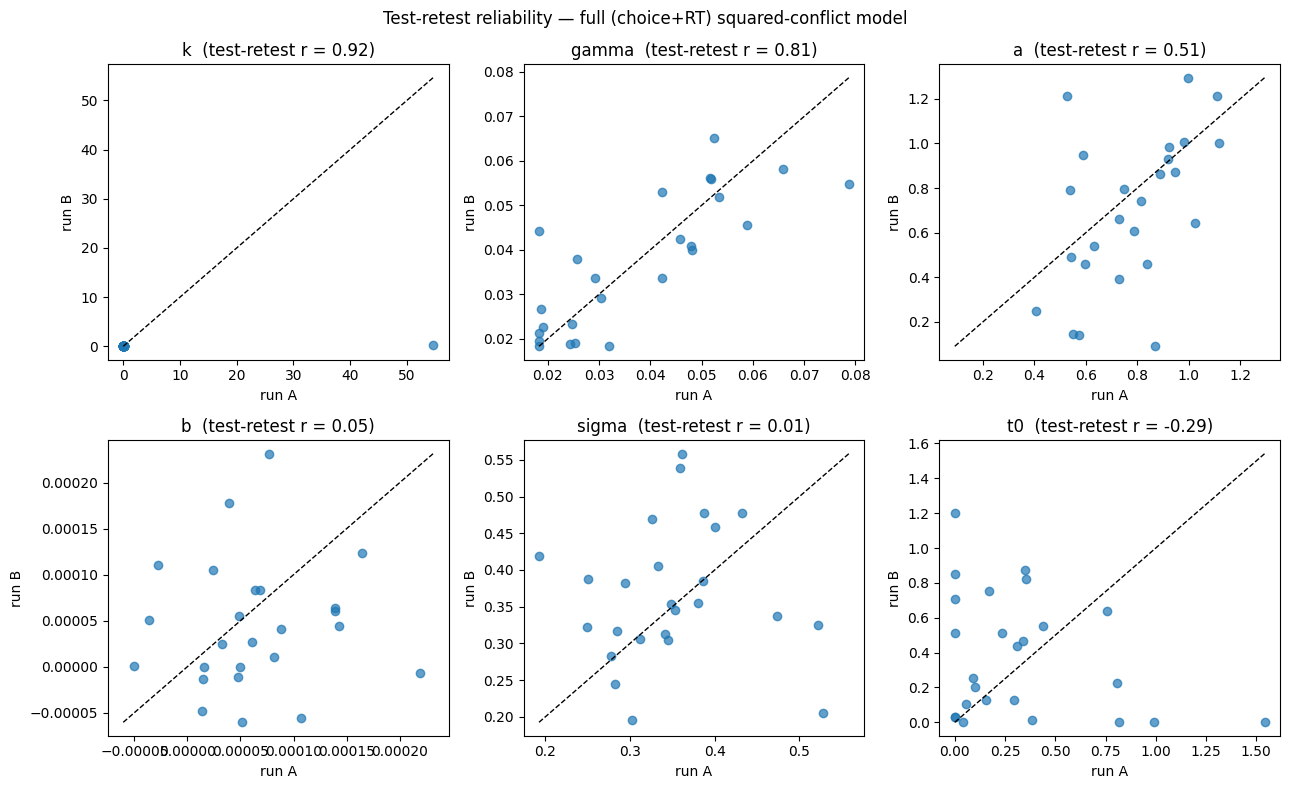

Test-retest reliability (full model):
  k      r = 0.921
  gamma  r = 0.807
  a      r = 0.508
  b      r = 0.053
  sigma  r = 0.010
  t0     r = -0.292

Test-retest reliability (choice-only baseline) vs (choice+RT), k & gamma:
  k      choice-only r = 0.750   |   choice+RT r = 0.921
  gamma  choice-only r = 0.846   |   choice+RT r = 0.807


In [12]:
fitB_full, fitB_base = {}, {}
for pid, d in participants.items():
    fitB_full[pid] = fit_full(d["test"])
    fitB_base[pid] = fit_choice_only(d["test"])

fitB_full_df = pd.DataFrame(fitB_full).T
fitB_base_df = pd.DataFrame(fitB_base).T

fig, axes = plt.subplots(2, 3, figsize=(13, 8))
for ax, p in zip(axes.flat, params):
    x, y = fitA_full_df[p].astype(float), fitB_full_df[p].astype(float)
    ax.scatter(x, y, alpha=0.7)
    lims = [min(x.min(), y.min()), max(x.max(), y.max())]
    ax.plot(lims, lims, "k--", lw=1)
    r, _ = pearsonr(x, y)
    ax.set_title(f"{p}  (test-retest r = {r:.2f})")
    ax.set_xlabel("run A"); ax.set_ylabel("run B")
fig.suptitle("Test-retest reliability — full (choice+RT) squared-conflict model")
fig.tight_layout()
plt.savefig("reliability_full_model.png", dpi=150)
plt.show()

print("Test-retest reliability (full model):")
for p in params:
    r, _ = pearsonr(fitA_full_df[p].astype(float), fitB_full_df[p].astype(float))
    print(f"  {p:6s} r = {r:.3f}")

print("\nTest-retest reliability (choice-only baseline) vs (choice+RT), k & gamma:")
for p in ["k", "gamma"]:
    r_base, _ = pearsonr(fitA_base_df[p].astype(float), fitB_base_df[p].astype(float))
    r_full, _ = pearsonr(fitA_full_df[p].astype(float), fitB_full_df[p].astype(float))
    print(f"  {p:6s} choice-only r = {r_base:.3f}   |   choice+RT r = {r_full:.3f}")


## 8. Out-of-sample evaluation (predict run B from run-A fits)

Two **separate** predictive quantities, per the assignment's warning: joint (choice+RT)
log-likelihoods are not comparable to choice-only log-likelihoods, since the full model also
"pays" to predict RT.

- **Choice predictive quantity**: held-out choice log-lik / accuracy on run B, using run-A
  `(k, γ)` — computed identically for the full model and the choice-only baseline, so they *are*
  comparable to each other.
- **RT predictive quantity**: held-out RT log-lik on run B, using run-A `(k, γ, a, b, σ, t0)` —
  only defined for the full model (the baseline makes no RT prediction).

Both are reported **overall and split by condition** (`1 = reward, 2 = loss`), as required.


In [13]:
def choice_pred_loglik(df, k, gamma):
    dV = hyperbolic_dV(df.r_imm.values, df.r_del.values, df.delay.values, k, df.condition.values)
    p = np.clip(choice_prob_delayed(dV, gamma), 1e-10, 1 - 1e-10)
    y = (df.choice.values == 2).astype(float)
    ll = y * np.log(p) + (1 - y) * np.log(1 - p)
    acc = np.mean((p > 0.5).astype(int) == y)
    return ll, acc

def rt_pred_loglik(df, k, gamma, a, b, sigma, t0):
    dV = hyperbolic_dV(df.r_imm.values, df.r_del.values, df.delay.values, k, df.condition.values)
    return rt_logpdf_squared_conflict(df.rt.values, dV, a, b, sigma, t0)

records = []
for pid, d in participants.items():
    df_test = d["test"]
    pf, pb = fitA_full[pid], fitA_base[pid]
    ll_full, acc_full = choice_pred_loglik(df_test, pf["k"], pf["gamma"])
    ll_base, acc_base = choice_pred_loglik(df_test, pb["k"], pb["gamma"])
    ll_rt = rt_pred_loglik(df_test, pf["k"], pf["gamma"], pf["a"], pf["b"], pf["sigma"], pf["t0"])
    cond = df_test.condition.values
    for c_label, c_val in [("overall", None), ("reward", 1), ("loss", 2)]:
        mask = np.ones(len(cond), dtype=bool) if c_val is None else (cond == c_val)
        if mask.sum() == 0:
            continue
        records.append(dict(
            pid=pid, condition=c_label, n_trials=int(mask.sum()),
            choice_ll_full=ll_full[mask].mean(), choice_ll_base=ll_base[mask].mean(),
            choice_acc_full=np.mean((ll_full[mask] > np.log(0.5))),  # per-trial correct-call proxy
            rt_ll_full=np.nanmean(ll_rt[mask][np.isfinite(ll_rt[mask])]) if np.isfinite(ll_rt[mask]).any() else np.nan,
        ))
oos_df = pd.DataFrame(records)
oos_summary = oos_df.groupby("condition")[["choice_ll_full", "choice_ll_base", "rt_ll_full"]].mean()
print("Mean per-trial predictive log-lik on run B, by condition:")
oos_summary


Mean per-trial predictive log-lik on run B, by condition:


,choice_ll_full,choice_ll_base,rt_ll_full
condition,,,
loss,-0.627208,-0.626367,-1.092260
overall,-0.624121,-0.619972,-1.088454
reward,-0.620754,-0.613398,-1.082351


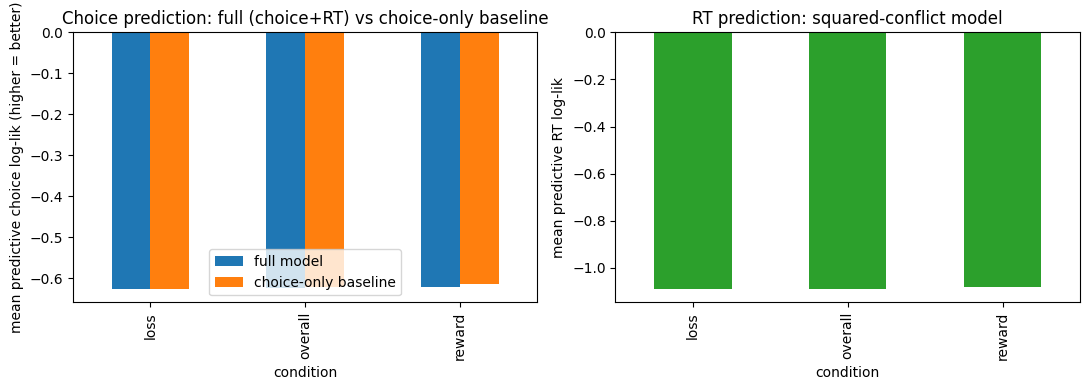

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
oos_summary[["choice_ll_full", "choice_ll_base"]].plot(kind="bar", ax=ax[0])
ax[0].set_ylabel("mean predictive choice log-lik (higher = better)")
ax[0].set_title("Choice prediction: full (choice+RT) vs choice-only baseline")
ax[0].legend(["full model", "choice-only baseline"])

oos_summary[["rt_ll_full"]].plot(kind="bar", ax=ax[1], legend=False, color="tab:green")
ax[1].set_ylabel("mean predictive RT log-lik")
ax[1].set_title("RT prediction: squared-conflict model")
fig.tight_layout()
plt.savefig("oos_prediction_summary.png", dpi=150)
plt.show()


## 9. Does RT help?

Compare, on the **choice** predictive quantity only (per the warning above):
(a) held-out choice log-lik / accuracy, full vs. choice-only baseline;
(b) parameter recovery correlations for `k, γ`, full vs. choice-only (Section 6);
(c) test–retest reliability for `k, γ`, full vs. choice-only (Section 7).


Choice predictive log-lik, full vs choice-only baseline (n=25 participants):
  mean(full - baseline) = -0.0041   (32% of participants favor the full model)


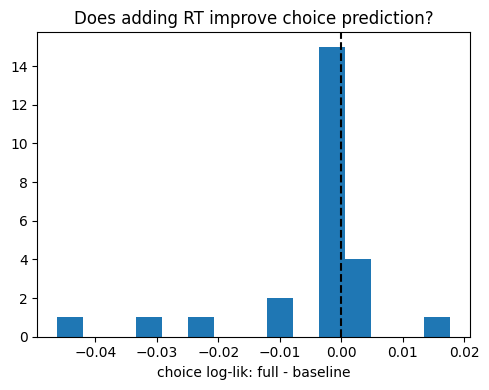

In [15]:
paired = oos_df[oos_df.condition == "overall"][["pid", "choice_ll_full", "choice_ll_base"]].set_index("pid")
diff = paired.choice_ll_full - paired.choice_ll_base
print(f"Choice predictive log-lik, full vs choice-only baseline (n={len(diff)} participants):")
print(f"  mean(full - baseline) = {diff.mean():.4f}   "
      f"({(diff > 0).mean()*100:.0f}% of participants favor the full model)")

fig, ax = plt.subplots(figsize=(5, 4))
ax.hist(diff, bins=15)
ax.axvline(0, color="k", ls="--")
ax.set_xlabel("choice log-lik: full - baseline")
ax.set_title("Does adding RT improve choice prediction?")
plt.tight_layout()
plt.savefig("does_rt_help_choice.png", dpi=150)
plt.show()


## 10. Recommendation & limitations (fill in after running on the real data)

**Template — replace bracketed text with your printed numbers:**

- Parameter recovery (Section 6): `[k/γ/a/b/σ/t0]` were well recovered (`r > 0.8`); `[…]` were
  poorly identified, most likely because `[…]` (e.g. trade-off between `a`,`b`,`t0` near
  `ΔV ≈ 0`).
- Reliability (Section 7): test–retest `r` was highest for `[…]` and lowest for `[…]`,
  suggesting `[…]` is the more stable, trait-like construct.
- Does RT help (Section 9): adding RT to the likelihood `[did / did not]` improve out-of-sample
  choice prediction (mean Δ log-lik `= […]`), and `[did / did not]` sharpen `k, γ` recovery and
  reliability relative to the choice-only baseline.
- **Recommendation**: based on the above, the squared-conflict RT model is/is not worth its
  extra two parameters relative to the choice-only baseline, because `[…]`. (Final
  cross-model recommendation — which of the group's 3+ RT models is best — should be made
  jointly using each model's `rt_ll_full` from Section 8 on a common held-out set.)
- **Limitations**: per-participant MLE (no hierarchical shrinkage) may be noisy for
  participants with few valid trials; `b`'s sign was left unconstrained during fitting even
  though the psychological hypothesis predicts `b > 0` — report how many participants had
  `b < 0` at the MLE; the loss-condition sign-flip in `hyperbolic_dV` is an assumption that
  should be checked against the real column definitions/codebook once real data is loaded.
